Conditioning -> generationg an image belonging to a predefined class -> guiding the output with additional informations

We'll use FMNIST dataset to do so : we'll provide the model with two inputs (1) the images (2) the class label each image belongs to.
(objective is that in addition to generate plausible image, we will ask him to generate it from a certain class)

**Prepare the dataset**

In [ ]:
import torch
from torchvision import transforms

preprocess= transforms.Compose(
    [transforms.RandomHorizontalFlip(),
     transforms.ToTensor(),
     transforms.Pad(2),
     transforms.Normalize([0.5],[0.5]),
     ]
)

In [ ]:
from torchvision import datasets, transforms
train_dataset = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=preprocess
)

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.4MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 198kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.65MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 15.4MB/s]


In [ ]:
import torch
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=256,shuffle=True
)

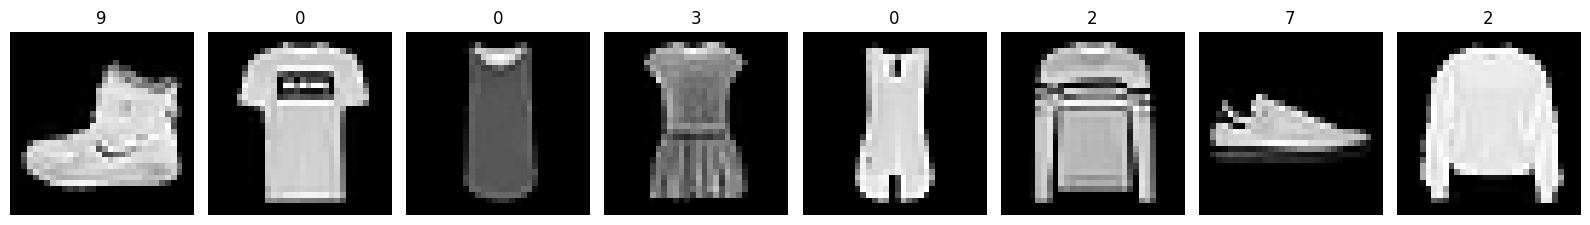

In [ ]:
import matplotlib.pyplot as plt

# Selection of the first 8 images and labels from the correctly transformed dataset
images = [train_dataset[i][0] for i in range(8)]
labels = [train_dataset[i][1] for i in range(8)]

# Display
plt.figure(figsize=(16, 4))  # width, height

for i in range(8):
    plt.subplot(1, 8, i + 1)
    # Use permute to change the channel dimension for matplotlib if necessary
    # FashionMNIST is grayscale, so squeeze is sufficient
    plt.imshow(images[i].squeeze(), cmap="gray", interpolation='nearest')
    plt.title(labels[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

**Creating a Class-Conditioned Model**
We use the same model as the one in Unconditional model. But we add a num_class_embeds argument to the UNet constructor. This argument tell the model we'd like to use class labels as additional conditioning.

In [ ]:
from diffusers import UNet2DModel

model = UNet2DModel(
    sample_size=32,
    in_channels=1,        # Images en niveaux de gris
    out_channels=1,       # Génère aussi une image en niveaux de gris
    block_out_channels=(32,64,128,256),
    num_class_embeds=10,
)

In [ ]:
x = torch.randn((1,1,32,32))
with torch.inference_mode():
  out = model(x,timestep=7,class_labels = torch.tensor([2])).sample # Le timestep est également un conditionnement, c'est un input supplémentaire pour la méthode forward

In [ ]:
  out.shape

torch.Size([1, 1, 32, 32])

Le timestep et les label sont transformés en embeddings que le model utilise durant le forward pass. Pendant plusieurs étapes du UNet, ces embeddings sont projetés dans les dimension qui match le nombre de channels dans un réseau.
Le vecteur est alors ajouté à l'output du réseau. Cela signifie que l'info du conditionnement nourri chaque bloque du Unet. Ce qui donne au modele l'occassion de l'apprendre efficacement.
La flexibilité des embeddings permet à la fois de s'occuper efficacement des différents types de conditionnements (timesteps, catégoriques, ou du texte).

**Entrainement du modèle**

In [ ]:
from diffusers import DDPMScheduler
scheduler = DDPMScheduler(
    num_train_timesteps=1000, beta_start=0.001,beta_end=0.02
)
timesteps = torch.linspace(0,999,8).long()
batch = next(iter(train_loader))
x = batch[0][0].expand([8,1,32,32])
noise = torch.rand_like(x)
noised_x = scheduler.add_noise(x,noise,timesteps)

In [ ]:
import matplotlib.pyplot as plt

def showimages(imm_batch):
  """Displays a batch of images using matplotlib."""
  num_images = imm_batch.shape[0]
  plt.figure(figsize=(16, 4))  # Adjust figure size as needed

  for i in range(num_images):
    plt.subplot(1, num_images, i + 1)
    # Permute and squeeze for matplotlib display
    # Clamp values to [0, 1] if they are normalized to [-1, 1]
    img_to_show = imm_batch[i].squeeze()
    # Assuming images are normalized to [-1, 1], convert to [0, 1] for display
    if img_to_show.min() < 0 or img_to_show.max() > 1:
        img_to_show = (img_to_show * 0.5 + 0.5).clamp(0, 1)

    plt.imshow(img_to_show.cpu().numpy(), cmap="gray", interpolation='nearest')
    # Note: Labels are not available in this function's scope, so title is omitted
    plt.axis("off")
    plt.title(f"Time : {timesteps[i].item()}") # Fix: Format title as a single string

  plt.tight_layout()
  plt.show()

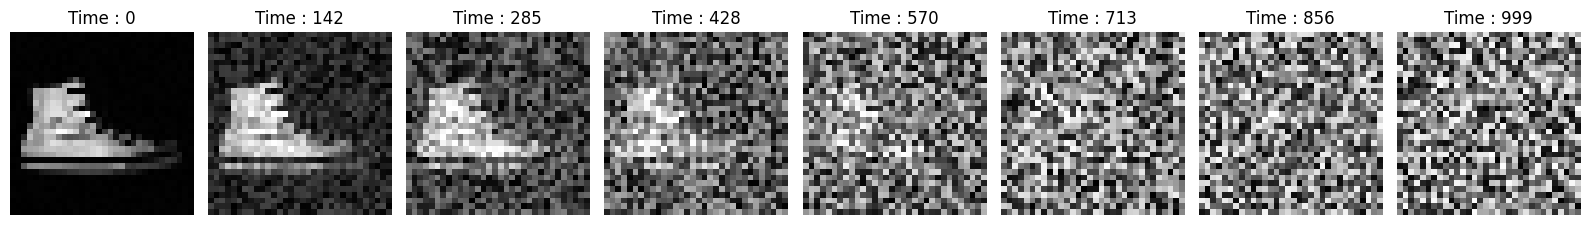

In [ ]:
showimages(noised_x)

In [ ]:
batch[1].size()

torch.Size([256])

In [ ]:
from torch.nn import functional as F
from tqdm import tqdm
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_epochs = 50
lr = 1e-4
optimizer = torch.optim.Adam(model.parameters(),lr=lr)
model.to(device) # Move the model to the selected device
losses = []  # (fixed: was commented out, causing a NameError at losses.append below)
for epoch in range(num_epochs):
  for step, batch in (inner:=tqdm(enumerate(train_loader),position=0,leave=True,total=len(train_loader),)):
    #batch = next(iter(train_loader))
    clean_images = batch[0].to(device)
    class_labels = batch[1].to(device)
    noise = torch.randn(clean_images.shape).to(device)
    timesteps = torch.randint(0,scheduler.config.num_train_timesteps, (clean_images.shape[0],), device=device).long()
    noisy_images = scheduler.add_noise(clean_images, noise, timesteps)
    noise_pred = model(noisy_images, timesteps,class_labels =class_labels, return_dict=False)[0]
    #Compare the prediction with the actual noise
    loss=F.mse_loss(noise_pred,noise)
    inner.set_postfix(loss=f"{loss.cpu().item():.3f}")
    losses.append(loss.item())
    #Backward pass
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

 75%|███████▍  | 176/235 [02:05<00:42,  1.40it/s, loss=0.039]


KeyboardInterrupt: 

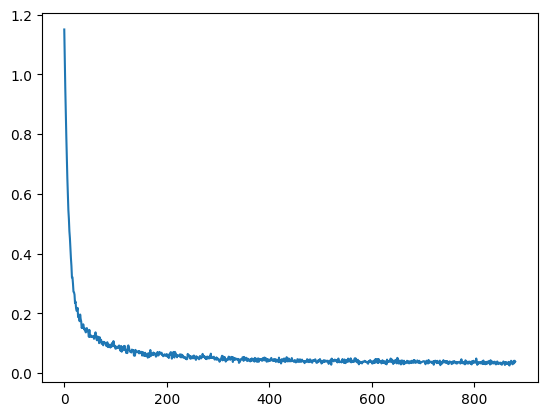

In [ ]:
plt.plot(losses)

In [ ]:
import torch

# Enregistrement
#torch.save(model.state_dict(), 'model_weights.pth')

# Pour charger plus tard :
#model.load_state_dict(torch.load('model_weights.pth'))
#model.eval()


In [ ]:
from tqdm import tqdm
def generate_from_class(class_to_generate,n_samples=8):
  sample = torch.randn(n_samples,1,32,32).to(device)
  class_labels = [class_to_generate]*n_samples
  class_labels = torch.tensor(class_labels).to(device)
  for _, t in tqdm(enumerate(scheduler.timesteps)):
    with torch.inference_mode():
      noise_pred = model(sample,t,class_labels=class_labels).sample
    sample = scheduler.step(noise_pred, t, sample).prev_sample
  return sample

In [ ]:
dico_class_sample = {}
for i in range(10):
  images = generate_from_class(i)
  dico_class_sample[i] = images

1000it [00:27, 36.42it/s]
1000it [00:27, 36.50it/s]
1000it [00:26, 37.42it/s]
1000it [00:26, 37.19it/s]
1000it [00:26, 37.36it/s]
1000it [00:28, 34.94it/s]
1000it [00:26, 37.15it/s]
1000it [00:27, 35.89it/s]
1000it [00:27, 36.76it/s]
1000it [00:27, 36.60it/s]


In [ ]:
images.size()

torch.Size([8, 1, 32, 32])

In [ ]:
import matplotlib.pyplot as plt

def showimagesresult(imm_batch):
  """Displays a batch of images using matplotlib."""
  num_images = imm_batch.shape[0]
  plt.figure(figsize=(16, 4))  # Adjust figure size as needed

  for i in range(num_images):
    plt.subplot(1, num_images, i + 1)
    # Permute and squeeze for matplotlib display
    # Clamp values to [0, 1] if they are normalized to [-1, 1]
    img_to_show = imm_batch[i].squeeze()
    # Assuming images are normalized to [-1, 1], convert to [0, 1] for display
    if img_to_show.min() < 0 or img_to_show.max() > 1:
        img_to_show = (img_to_show * 0.5 + 0.5).clamp(0, 1)

    plt.imshow(img_to_show.cpu().numpy(), cmap="gray", interpolation='nearest')
    # Note: Labels are not available in this function's scope, so title is omitted
    plt.axis("off")

  plt.tight_layout()
  plt.show()

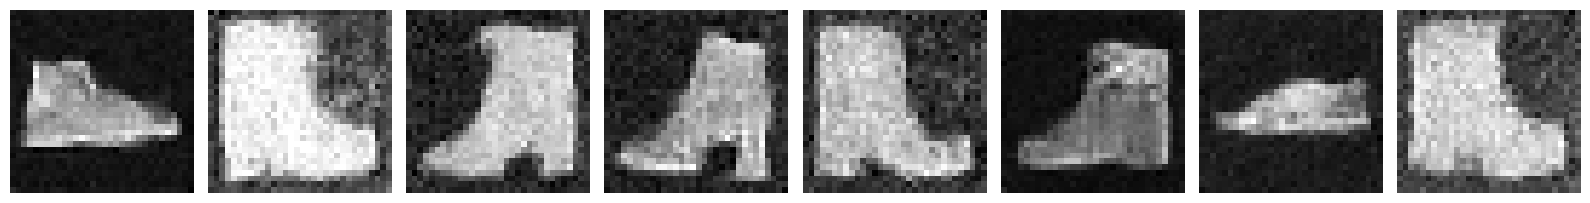

In [ ]:
showimagesresult(dico_class_sample[9])

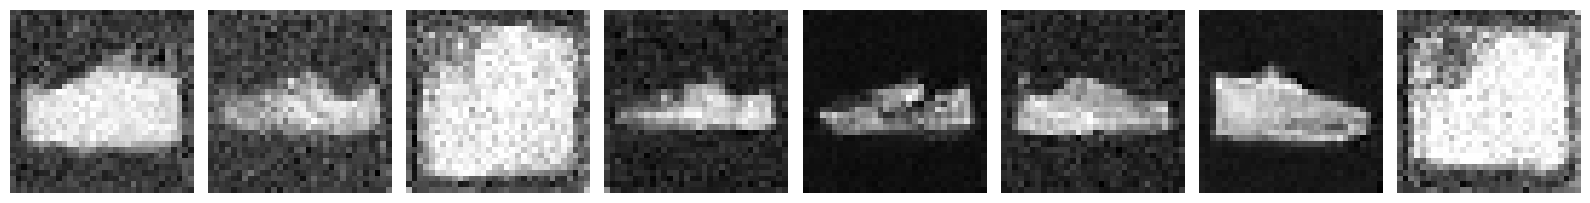

In [ ]:
showimagesresult(dico_class_sample[7])

Piste pour améliorer le modèle from scratch ?

PB1 : Sur un batch donné il y'a des échantillons bons et d'autres bcp moins bons/très bruités

PB2 : Le modèle est meilleur sur certaines classes que d'autres

**Stable Latent Diffusion **

*[Course diagram omitted — see the referenced course material]*

**Some words on Stable Diffusion :**

Big issue with conditional model is that as image size grows, so does the computational power required to work with those image.
(Example self-attention : the amount of operations grows quadritically with the number of inputs.) -> Latent Diffusion tries to mitigate this issue by using VAE which can learn to produce a much smaller representation of an input image and then reconstruct the image with high fidelity based on this small representation. (In Stable Diffusion : 3 x 512 x 512 -> 4 x 64 x 64)

Stable Diffusion is a Latent Diffusion model that can generate images conditioned on text prompts. It can also be used to modify images.



/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

model.fp16.safetensors:   0%|          | 0.00/246M [00:00<?, ?B/s]

model.fp16.safetensors:   0%|          | 0.00/608M [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.06M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

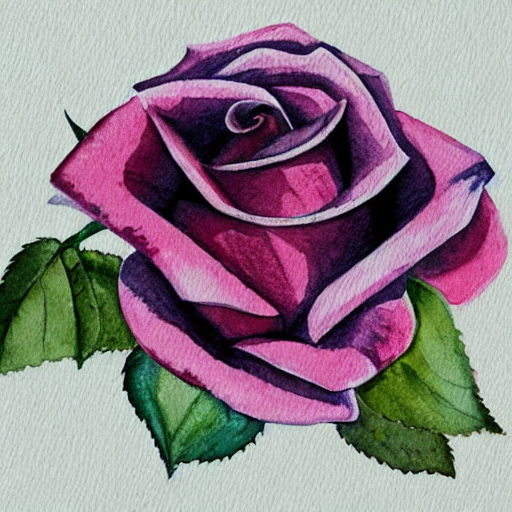

In [ ]:
from diffusers import StableDiffusionPipeline
pipe = StableDiffusionPipeline.from_pretrained(
    "stable-diffusion-v1-5/stable-diffusion-v1-5",
    torch_dtype = torch.float16,
    variant="fp16",
).to(device)

  0%|          | 0/50 [00:00<?, ?it/s]

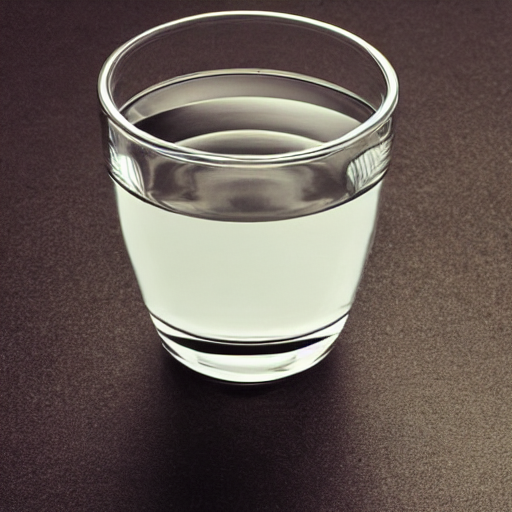

In [ ]:
pipe("A glass of water").images[0]

We should explore all the diffusion model Pipeline

**Text Prompt**

In the case of Stable Diffusion, the additional clue are (not classes but) the text prompt. At inference time, we feed the description of an image we'd like to generate and some pure noise as a starting point, and the model does its best to denoise the random input into something that matches the caption.

**Text Encoder**
To accomplish this, we'll use a text encoder that turns an input string into text embeddings which are then fed into the UNET along with the timestep and the noisy latents*[Course diagram omitted — see the referenced course material]*

To do this, Stable Diffusion leverages a **pretrained transformer model** based on CLIP. The text encoder is a transformer that takes in a sequences of tokens and produces a vector for each token, as can be seen in the figure below. (original CLIP -> 768 dimensional vector/ StableDiff2 -> 1024 for each token)
Instead of combining the vectors of all tokens into a single representation, we keep them separate and use them as conditioning for the UNet. This allows the UNet to use the information in each token separately rather than just the overall meaning of the prompt.

*[Course diagram omitted — see the referenced course material]*

In [ ]:
prompt = "A photograph of a puppy"
text_input = pipe.tokenizer(
    prompt,
    return_tensors="pt",
)
for t in text_input["input_ids"][0]:
  print(t,pipe.tokenizer.decoder.get(int(t)))

tensor(49406) <|startoftext|>
tensor(320) a</w>
tensor(8853) photograph</w>
tensor(539) of</w>
tensor(320) a</w>
tensor(6829) puppy</w>
tensor(49407) <|endoftext|>


La première étape pour encoder un texte est de faire une "tokenization", ce qui permet de convertir une séquence de caractères en séquence de nombres.

Dans tous les modèles de type Transformer (comme ceux utilisés dans Stable Diffusion, GPT, BERT, etc.), chaque token est représenté par un entier, c'est ce qu'on appelle l'index de vocabulaire.Chaque mot ou morceau de mot a un ID unique, et c'est cette représentation numérique que comprend le modèle.
"photograph" est associé nombre 8853 du vocabulaire du tokenizer. Il y'a aussi des tokens spéciaux qui apportent du contexte, etc.

In [ ]:
text_embeddings = pipe.text_encoder(text_input.input_ids.to(device))[0]
print("Taille du vecteur d'embeddings : ",text_embeddings.size())

Taille du vecteur d'embeddings :  torch.Size([1, 7, 768])


Ici on travaille avec CLIP, il encode chaque token en un vecteur dans R^768.

**The VAE is tasked with compressing images into a smaller representation and reconstructing them again**

*[Course diagram omitted — see the referenced course material]*

reconstruction loss + KL divergence + patch-based discriminator loss

Like the text encoder, VAE is trained separately

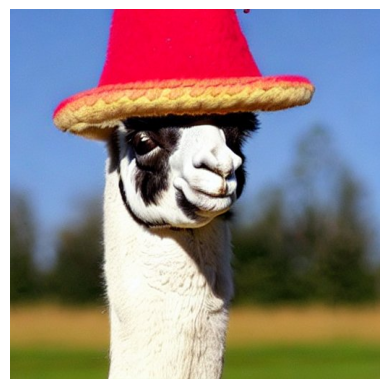

In [ ]:
from genaibook.core import load_image,show_image,SampleURL
im = load_image(
    SampleURL.LlamaExample,
    size=(512,512)
)
show_image(im);

Let's pass the image Through the VAE.
Scale the latent vector by a fixed size of 0.18215. The Stable Diffusion authors introduced this scaling factor of 0.18215 to ensure that the latent space has a variance close to 1, matching the approximate scale of the noise added during the diffusion process. It can be accessed in vae.config.scaling_factor.

Scaling factor - Classifier free guidance

In [ ]:
import torch
from torchvision import transforms

# Assuming 'device' is already defined (e.g., device = torch.device("cuda" if torch.cuda.is_available() else "cpu"))
# Assuming 'pipe' is already defined and contains the VAE

with torch.inference_mode():
  #Process the image
  tensor_im = transforms.ToTensor()(im).unsqueeze(0).to(device)*2 - 1
  tensor_im = tensor_im.half()

  #Encode the image
  # The encoder outputs a tensor with concatenated mean and log variance
  latent = pipe.vae.encode(tensor_im)

  # Sample from the latent distribution
  latents = latent.latent_dist.sample()
  latents = latents*0.18215
  latents.shape

In [ ]:
import matplotlib.pyplot as plt

def show_images(images, titles=None):
    """
    Displays a list of images.

    Args:
        images (list): A list of image tensors or arrays.
        titles (list, optional): A list of titles for each image. Defaults to None.
    """
    n_images = len(images)
    fig, axes = plt.subplots(1, n_images, figsize=(5 * n_images, 5))

    if n_images == 1:
        axes = [axes] # Make axes iterable for single image case

    for i, (img, ax) in enumerate(zip(images, axes)):
        # Convert tensor to numpy array and handle different data types and dimensions
        if torch.is_tensor(img):
            img = img.detach().cpu().numpy()
        if img.ndim == 3 and img.shape[0] in [1, 3]: # Handle channels first
             img = img.transpose(1, 2, 0)
        elif img.ndim == 2: # Handle grayscale
             pass
        else:
             print(f"Warning: Could not display image at index {i} with shape {img.shape}")
             continue

        ax.imshow(img, cmap='gray' if img.ndim == 2 else None)
        ax.axis('off')
        if titles and i < len(titles):
            ax.set_title(titles[i])

    plt.tight_layout()
    plt.show()

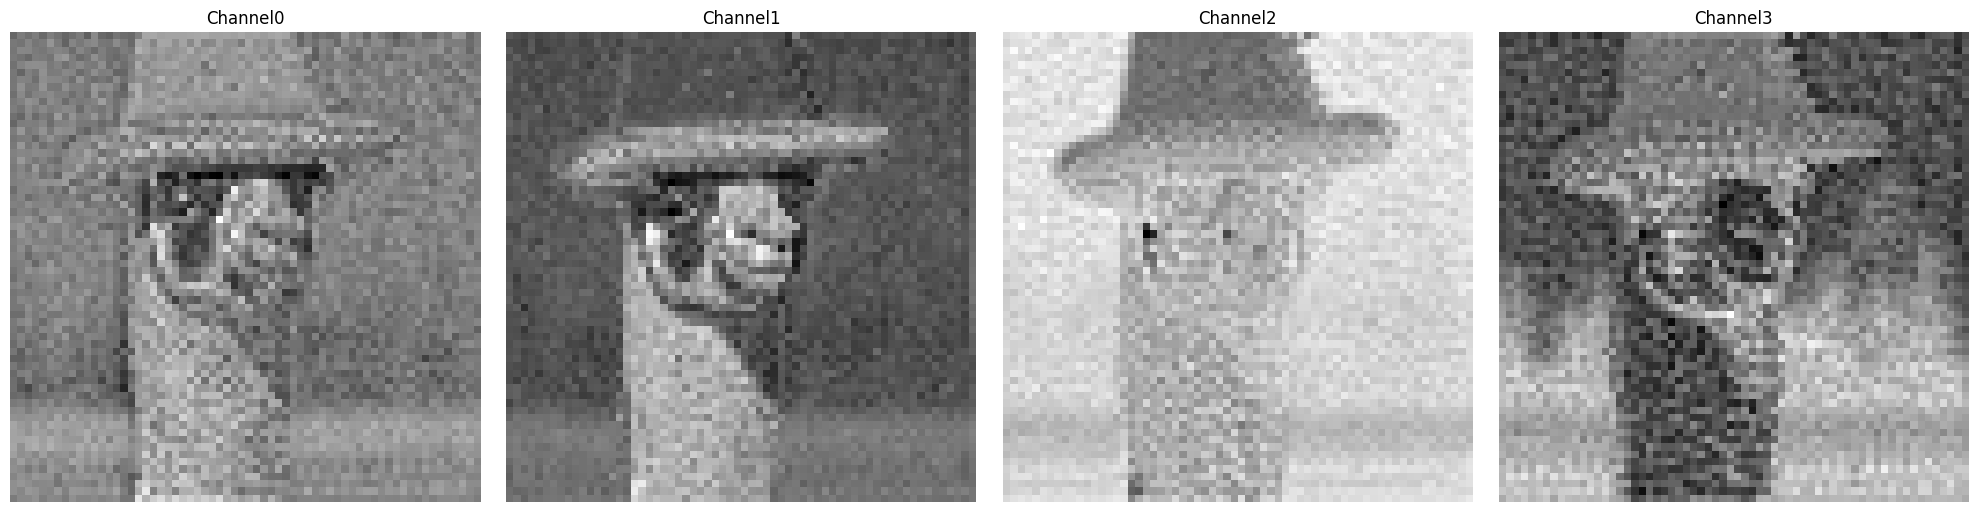

In [ ]:
show_images(
    [l for l in latents[0]],
    titles =[f"Channel{i}" for i in range(latents.shape[1])]
)

Maintenant que l'on a encodé l'image dans un espace latent, on va la décoder. Dans l'idéal, l'image devrait être identique. En réalité, il arrive que le modèle introduise des artefacts et du bruit.

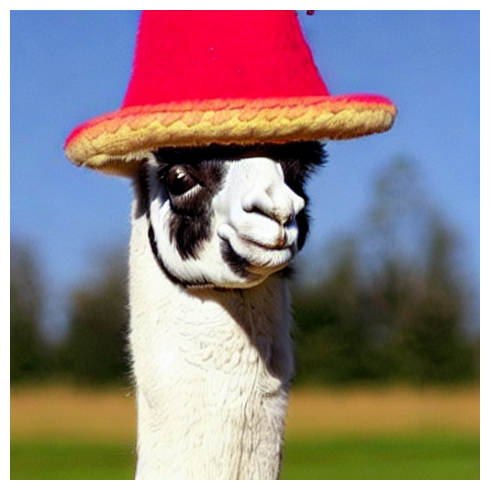

In [ ]:
with torch.inference_mode():
  image = pipe.vae.decode(latents / 0.18215).sample
image = (image / 2 + 0.5).clamp(0,1).unsqueeze(0)
show_images(image[0].float())